# Can kinematics predict sprint velocity?

## Why this notebook exists

Notebook 01 described *how* these athletes move. This one asks whether that
description **predicts how fast they go** — and answers it with cross-validation
rather than with a line fitted to the same 30 people it is scored on.

Three things shape everything below.

**n = 30.** That is the hard ceiling. With 30 athletes and 22 candidate features
a model can fit the cohort perfectly and predict nothing. Every number here is
**leave-one-out**: fit on 29, predict the 30th, and score only predictions made
for someone the model had never seen.

**Two pieces of feature engineering**, both asked for before any model was run:
limbs ordered by range of motion rather than by anatomical side, and the two
collinear separation angles dropped.

**Nothing crosses the fold.** Standardisation, the fPCA basis and the ridge
penalty are all refit on the training 29. Fitting any of them on all 30 first
lets the held-out athlete influence its own prediction.

The figures are drawn by `sprint_outputs.py`, which is also what renders them
for the whole cohort in one call.

In [1]:
import numpy as np
import pandas as pd
import scipy.stats as st
from sklearn.linear_model import LinearRegression, RidgeCV

import sprint_pipeline as SP
from sprint_pipeline import *
import sprint_outputs as OUT       # sections 7-8: the figures

ridge = lambda: RidgeCV(alphas=np.logspace(-3, 4, 60))
print(f"{len(PARTICIPANT_ANTHRO)} participants in the sheet, excluding {EXCLUDED_PIDS}")

31 participants in the sheet, excluding ['SB17']


## A · Build the table

One pass over the cohort. For each athlete: the top-speed angle cycle, the same
cycle recoded by range of motion, the scalar features, the velocity curve and
both versions of its peak.

Velocity is **unscaled** throughout. The 1.75 m height rescaling used for the
figures and MP4s never reaches the model — scaling an athlete's body also scales
the speed derived from it, so a scaled target would partly measure the scaling.

In [2]:
feat = SP.build_feature_table()

X, y, y_raw, height = feat["X"], feat["y"], feat["y_raw"], feat["height"]
pids = list(y.index)
feat["X"].head(4).iloc[:, :6]

30 athletes, 22 scalar features
target  : 6.39-9.35 m/s (sd 0.72)
smoothing removed +0.52 m/s of noise from the peak (range +0.26 to +0.83)
acceleration cycles available for 30 athletes


,hip_hi_ROM,hip_hi_mean,hip_lo_ROM,hip_lo_mean,knee_hi_ROM,knee_hi_mean
SB061,77.152459,25.992898,73.849304,27.176787,122.856848,71.081118
SB101,67.606898,12.769269,59.496499,10.244787,105.570802,57.435627
SB102,65.140726,10.465456,56.946625,14.466101,116.894629,66.098800
SB110,62.679331,20.197550,60.156714,16.539011,119.880510,71.654118


## B · Cleaning the target

`compute_velocity` differentiates marker position at 60 Hz. A 1 mm tremor becomes
6 cm/s of fake velocity, and taking the **maximum** of that noisy trace picks out
the largest upward blip — so the peak is biased high *by construction*.

Across this cohort the raw peak runs **+0.52 m/s hot**, and by different amounts
for different athletes, which makes it noise rather than an offset.

The fix is the machinery already smoothing the angle curves: fit a penalised
B-spline and read the peak off the **function** instead of off the samples.

saved velocity_bspline_fit.png


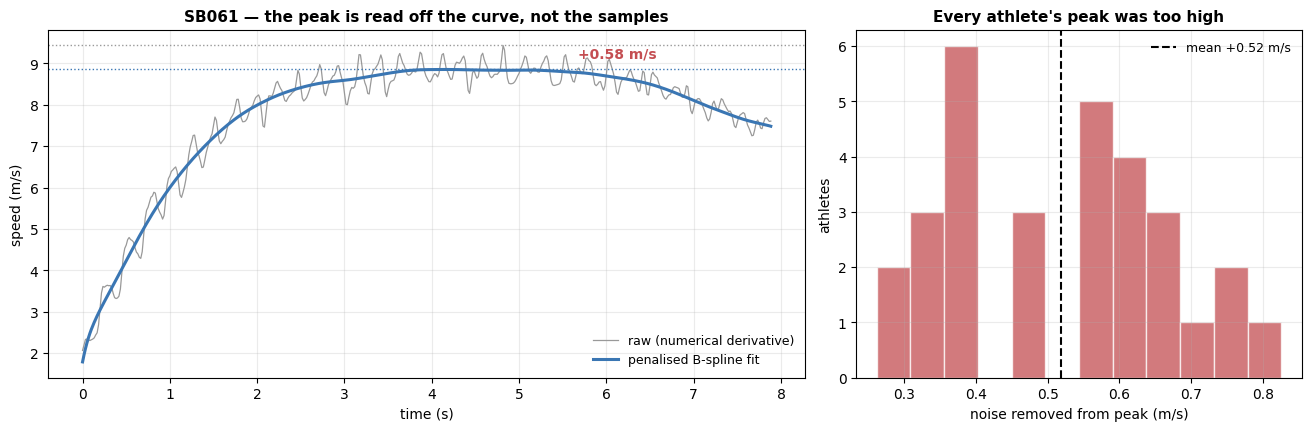

In [3]:
print("saved", OUT.plot_velocity_fit(feat).name)

### Does the smoothing penalty change the answer?

A knob that moves the result is a knob the analyst is turning, so it is worth
checking rather than asserting. The default penalty is the median of a
per-athlete GCV selection; below is what happens across five orders of magnitude
either side of it.

In [4]:
SP.velocity_penalty_sweep(feat)

,penalty,edf,mean_peak_ms,noise_removed_ms,r_knee_ROM
0,0.01,56.5,8.211,0.420,-0.520
1,0.10,45.2,8.180,0.451,-0.515
2,1.00,30.8,8.142,0.489,-0.511
3,10.00,19.4,8.119,0.512,-0.506
4,100.00,11.8,8.108,0.523,-0.501
5,1000.00,7.1,8.110,0.521,-0.496


The peak moves **0.10 m/s** across that entire range, against the **0.52 m/s**
the smoothing removes in the first place, and the correlation with knee range of
motion sits between −0.52 and −0.50 throughout. The conclusion does not depend
on the setting.

One honest consequence. The *raw* peak correlates with knee ROM at **−0.554**;
every smoothed version lands between −0.52 and −0.50. Since the correlation is flat across
all penalties, that gap is not over-smoothing — it means a small part of the raw
peak's relationship was carried by the noise the smoothing removed. The smoothed
target is used from here on, with the raw one kept alongside so the difference
stays visible.

## C · Feature cleaning 1 — limbs ordered by range of motion

"Right hip" is not the same thing in every athlete. Some sprinters drive harder
with the left leg, some with the right, so averaging a right-hand column across
the cohort averages the big side of one athlete with the small side of another —
smearing exactly the variation the model is meant to find.

In [5]:
side = pd.DataFrame([SP.limb_rom_order(feat["cycles"][p]) for p in pids], index=pids)
allsame = ((side.sum(axis=1) == 0) | (side.sum(axis=1) == 5)).sum()
legs    = side[["hip", "knee", "ankle"]]
print(f"all five joints agree on one side : {allsame}/{len(pids)} athletes")
print(f"leg chain alone (hip/knee/ankle)  : {int(((legs.sum(axis=1)==0)|(legs.sum(axis=1)==3)).sum())}/{len(pids)}")
print(f"left is the larger-ROM limb in    : "
      + ",  ".join(f"{j} {side[j].mean()*100:.0f}%" for j in SP.PAIRED_JOINTS))

all five joints agree on one side : 0/30 athletes
leg chain alone (hip/knee/ankle)  : 3/30
left is the larger-ROM limb in    : hip 67%,  knee 40%,  ankle 37%,  shoulder 47%,  elbow 40%


No athlete has all five joints on the same side, and even the leg chain alone is
unanimous in a handful. Cross-joint agreement runs near chance. Handedness does
not produce a coherent whole-body side, so the ordering is decided
**independently for each joint**.

Two details make the recoding safe.

**Nothing is discarded.** The larger-ROM side becomes `_hi` and the other `_lo`.
The same numbers come out, relabelled.

**Phase is corrected.** The cycle runs right-contact to right-contact, so a right
limb starts at contact and a left limb starts half a cycle later. If `_hi` were
sometimes the raw left column, the HI curves would mix contact-referenced and
mid-cycle-referenced traces — and that phase difference would masquerade as
between-athlete variation. The left curve is rolled **+50 %**, the same
correction validated in notebook 01, where the shift gives r = 1.00 against 0.42
for the vertical flip it is often confused with.

In [6]:
half = 101 // 2
bad  = 0
for p in pids:
    cy, hl, order = feat["cycles"][p], feat["hilo"][p], SP.limb_rom_order(feat["cycles"][p])
    for k, j in enumerate(SP.PAIRED_JOINTS):
        r = cy[:, ANGLE_NAMES.index(j + "_R")]
        l = np.roll(cy[:, ANGLE_NAMES.index(j + "_L")], half)
        want = (l, r) if order[j] else (r, l)
        bad += not (np.allclose(hl[:, 2*k], want[0]) and np.allclose(hl[:, 2*k+1], want[1]))
print(f"recoding is lossless: {len(pids)} athletes x 5 joints, {bad} mismatches")

recoding is lossless: 30 athletes x 5 joints, 0 mismatches


### The asymmetry needs a noise floor

Taking the larger of two noisy paired measurements biases it upward, and the
smaller downward. So `ROM_hi − ROM_lo` comes out **positive even for a perfectly
symmetric athlete**, and reading it as biomechanics would be reading the
measurement error.

The floor is estimated within an athlete: the same limb measured on different
strides of the same run should give the same range, so the spread of that
repeated measurement is the noise. Anything below that line is not evidence of
asymmetry.

saved limb_rom_asymmetry.png


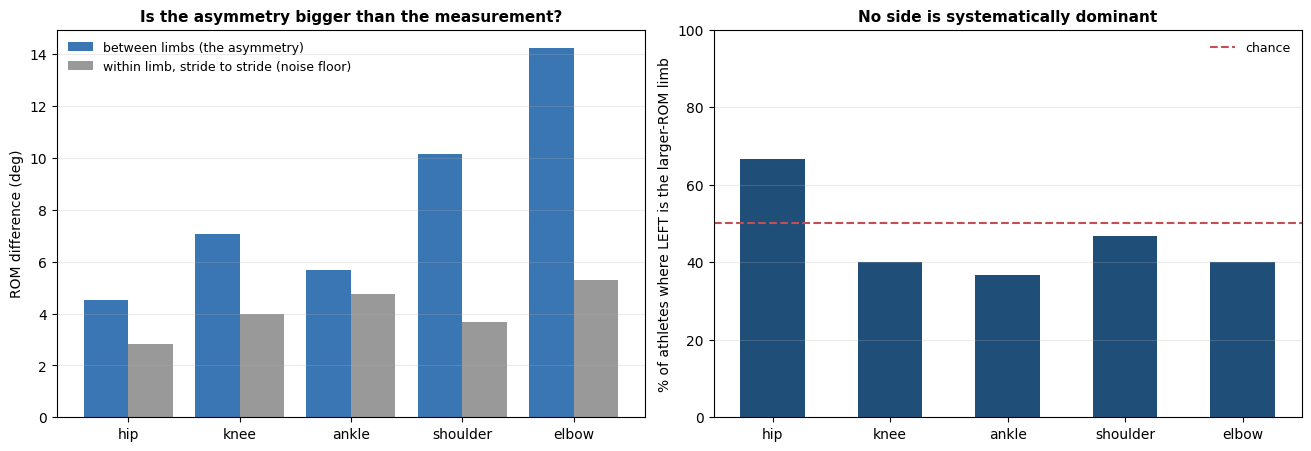

In [7]:
print("saved", OUT.plot_limb_asymmetry(feat).name)

**The arms carry the asymmetry; the legs barely do.** Elbow (14.2° against a
5.3° noise floor) and shoulder (10.2° against 3.7°) clear their floors by a wide
margin — which is where handedness would be expected to show. The ankle does
not: 5.7° against a 4.8° floor is close enough to the measurement that it should
not be read as asymmetry at all. Hip and knee sit in between.

So the recoding does real work at the arms and mostly reorders noise at the
ankle. Worth remembering if a HI/LO ankle feature ever turns up in a model.

## D · Feature cleaning 2 — drop the collinear columns

Two of the thirteen angles are exact arithmetic of two others.

In [8]:
cy = feat["cycles"][pids[0]]
i = ANGLE_NAMES.index
print("thigh_separation == hip_R - hip_L          :",
      np.allclose(cy[:, i("thigh_separation")], cy[:, i("hip_R")] - cy[:, i("hip_L")]))
print("arm_separation   == shoulder_R - shoulder_L:",
      np.allclose(cy[:, i("arm_separation")], cy[:, i("shoulder_R")] - cy[:, i("shoulder_L")]))
print(f"\nso the 13-angle matrix has rank {np.linalg.matrix_rank(cy)}, not 13")

thigh_separation == hip_R - hip_L          : True
arm_separation   == shoulder_R - shoulder_L: True

so the 13-angle matrix has rank 11, not 13


They carry no information of their own; they weight hip and shoulder twice. Both
are dropped from the model, leaving the 11 HI/LO columns. Under the recoding the
same quantity is available as `hip_hi − hip_lo` anyway.

## E · fPCA scores as features

Notebook 01's components describe the shape of the whole cycle rather than one
summary number, so they are the natural functional feature. They are computed
both ways — anatomical R/L and recoded HI/LO.

**The basis is refit inside every fold.** Running `run_angle_fpca` on all 30 and
then cross-validating only the regression would let every athlete help build the
axes used to predict them. It is the easiest way to fake a small-n result, and
the difference it makes is measured directly below.

In [9]:
rl_t   = SP.fpca_fold_transform(feat["cycles"], pids, 6)
hilo_t = SP.fpca_fold_transform(feat["hilo"],   pids, 6)

for name, curves, t in [("R/L", feat["cycles"], rl_t), ("HI/LO", feat["hilo"], hilo_t)]:
    leaked = SP.fit_metrics(y.values, SP.loo_predict(SP.fpca_scores_leaky(curves, pids, 6),
                                                     y.values, ridge))["LOO_R2"]
    honest = SP.fit_metrics(y.values, SP.loo_predict(None, y.values, ridge, t))["LOO_R2"]
    print(f"  {name:6} fPCA fitted on all 30 = {leaked:+.3f}    refit inside fold = {honest:+.3f}")

  R/L    fPCA fitted on all 30 = -0.223    refit inside fold = -0.188


  HI/LO  fPCA fitted on all 30 = -0.200    refit inside fold = -0.139


Both are **worse than guessing the mean**, and the leaked version is no better
than the honest one. That is not a licence to leak — it is what leakage looks
like when the leaked feature carries no signal. Inflating a score requires
something to inflate, and PC1 correlates with velocity at only r = −0.24.

The leak that *does* bite this project is **selection**, not projection.

In [10]:
names = list(X.columns)
def topk(Xs, ys, k):
    rr = np.array([abs(np.corrcoef(Xs[:, j], ys)[0, 1]) for j in range(Xs.shape[1])])
    return np.argsort(-rr)[:k]

Xv = X.values
for k in (1, 2, 3, 5):
    sel    = topk(Xv, y.values, k)
    leaked = SP.fit_metrics(y.values, SP.loo_predict(Xv[:, sel], y.values))["LOO_R2"]
    honest = SP.fit_metrics(y.values, SP.loo_predict(
        None, y.values, None, lambda tr, te, _k=k: (Xv[tr][:, topk(Xv[tr], y.values[tr], _k)],
                                                    Xv[te][:, topk(Xv[tr], y.values[tr], _k)])))["LOO_R2"]
    print(f"  top {k}: chosen on all 30 = {leaked:+.3f}    chosen inside fold = {honest:+.3f}"
          f"    inflation = {leaked-honest:+.3f}")

  top 1: chosen on all 30 = +0.278    chosen inside fold = +0.278    inflation = +0.000
  top 2: chosen on all 30 = +0.220    chosen inside fold = +0.220    inflation = +0.000


  top 3: chosen on all 30 = +0.228    chosen inside fold = +0.072    inflation = +0.156
  top 5: chosen on all 30 = +0.188    chosen inside fold = -0.046    inflation = +0.234


At **k = 3 the inflation is +0.156** and at k = 5 it is **+0.234** — a model that
looks respectable collapses to nothing once the choice of features is made
honestly. At k = 1 and k = 2 there is
no gap, because the same feature wins in every fold; a stable choice costs
nothing, an unstable one costs everything.

### Was knee ROM worth finding?

Notebook 01 reported knee ROM at r = −0.576, the largest of 26 correlations. A
largest-of-many is not the same as a correlation, so it needs its own null: how
big does the biggest of 22 correlations get when the target is shuffled?

In [11]:
rng, mx = np.random.default_rng(0), []
for _ in range(4000):
    yp = rng.permutation(y.values)
    mx.append(max(abs(np.corrcoef(Xv[:, j], yp)[0, 1]) for j in range(Xv.shape[1])))
mx  = np.array(mx)
obs = max(abs(np.corrcoef(Xv[:, j], y.values)[0, 1]) for j in range(Xv.shape[1]))
best = names[int(np.argmax([abs(np.corrcoef(Xv[:, j], y.values)[0, 1]) for j in range(Xv.shape[1])]))]
print(f"largest |r| under the null : median {np.median(mx):.3f}, 95th pct {np.percentile(mx,95):.3f}")
print(f"largest |r| observed       : {obs:.3f}  ({best})")
print(f"                        p  = {(np.sum(mx>=obs)+1)/(len(mx)+1):.3f}   <- survives the search")

largest |r| under the null : median 0.377, 95th pct 0.525
largest |r| observed       : 0.597  (knee_lo_ROM)
                        p  = 0.009   <- survives the search


It survives. Knee range of motion is genuinely the strongest single feature, not
the winner of a lottery — so it enters the model on its merits, with the caveat
that it was **found by searching**, which is why the permutation test below is
run on the whole procedure rather than on the fitted line.

## F · The model ladder

Simplest first. Every row is leave-one-out, every preprocessing step refit inside
the fold.

The reference is not zero. An intercept-only model scores **−0.070** here,
because leave-one-out makes even the cohort mean slightly worse than the
full-sample mean. That is the honest zero line.

In [12]:
kneeROM = X[["knee_hi_ROM", "knee_lo_ROM"]].values
h       = height.values
combo   = np.column_stack([X.knee_hi_ROM, X.knee_lo_ROM, h])
n       = len(pids)

specs = [
    ("intercept only",           np.zeros((n, 1)),           None,  None),
    ("height only",              h[:, None],                 None,  None),
    ("knee ROM (hi + lo)",       kneeROM,                    None,  None),
    ("knee ROM + height",        combo,                      None,  None),
    ("fPC 1-6, R/L curves",      None,                       ridge, rl_t),
    ("fPC 1-6, HI/LO curves",    None,                       ridge, hilo_t),
    ("all 22 scalars, ridge",    Xv,                         ridge, None),
    ("all 22 + height, ridge",   np.column_stack([Xv, h]),   ridge, None),
]
ladder, preds = SP.model_ladder(specs, y.values)

  intercept only               LOO R2 = -0.070   RMSE = 0.735   MAE = 0.619
  height only                  LOO R2 = +0.097   RMSE = 0.675   MAE = 0.539
  knee ROM (hi + lo)           LOO R2 = +0.220   RMSE = 0.628   MAE = 0.514
  knee ROM + height            LOO R2 = +0.256   RMSE = 0.613   MAE = 0.471
  fPC 1-6, R/L curves          LOO R2 = -0.188   RMSE = 0.775   MAE = 0.646
  fPC 1-6, HI/LO curves        LOO R2 = -0.139   RMSE = 0.759   MAE = 0.637
  all 22 scalars, ridge        LOO R2 = -0.227   RMSE = 0.788   MAE = 0.638
  all 22 + height, ridge       LOO R2 = -0.087   RMSE = 0.741   MAE = 0.586


saved model_comparison_loocv.png


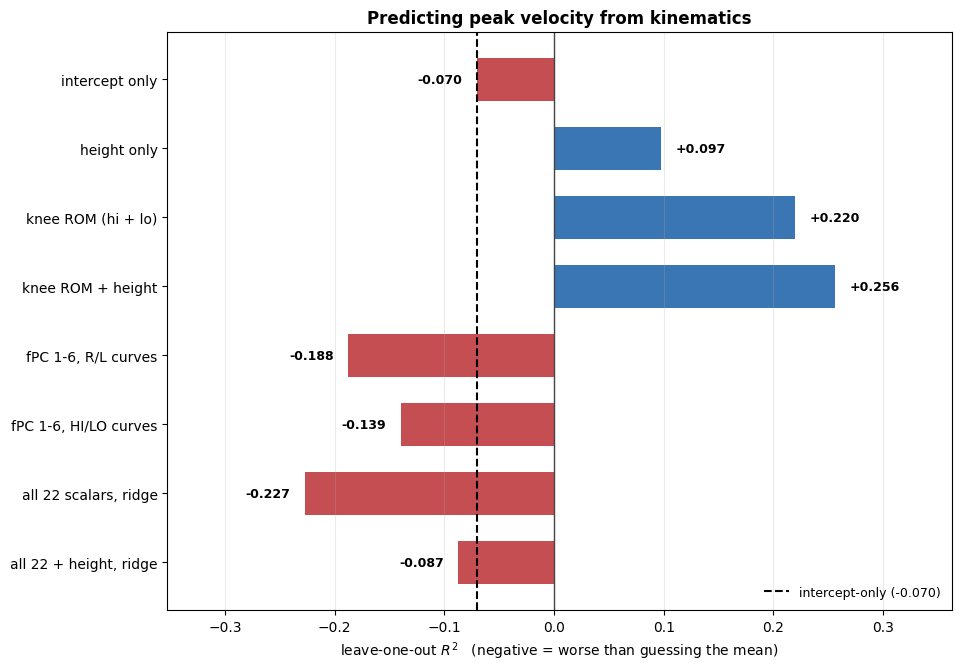

In [13]:
print("saved", OUT.plot_model_comparison(ladder, null_r2=-0.070).name)

**The small model wins.** Three features reach **LOO R² = +0.256**; twenty-two
features under ridge regression land *below* the intercept-only line. That is not
a quirk — it is what p ≈ n does, and it is the clearest argument in the notebook
for keeping the feature set short.

The fPC scores lose to the mean in both codings. The components describe the
movement well and predict speed badly, which is consistent with notebook 01,
where PC1 took 42 % of the variance and correlated r = −0.24 with velocity. **The
dominant way these athletes differ from each other is not the way that makes them
fast.**

Height alone reaches +0.097 and knee ROM alone +0.220; together they reach
+0.256, so each is carrying something the other is not.

## G · Is the fit real?

In [14]:
pred = SP.loo_predict(combo, y.values)
obs_r2, p_perm, null = SP.permutation_test(combo, y.values, n_perm=5000, seed=1)
print(f"knee ROM + height : LOO R2 = {obs_r2:+.3f}")
print(f"  permutation p = {p_perm:.4f}   (null 95th percentile = {np.percentile(null,95):+.3f})")
print()
m = SP.fit_metrics(y.values, pred, "final model")
print(f"  RMSE = {m['RMSE']:.3f} m/s   MAE = {m['MAE']:.3f} m/s"
      f"   (cohort spread = {y.std():.3f} m/s)")

knee ROM + height : LOO R2 = +0.256
  permutation p = 0.0024   (null 95th percentile = +0.019)

  RMSE = 0.613 m/s   MAE = 0.471 m/s   (cohort spread = 0.723 m/s)


saved model_diagnostics.png


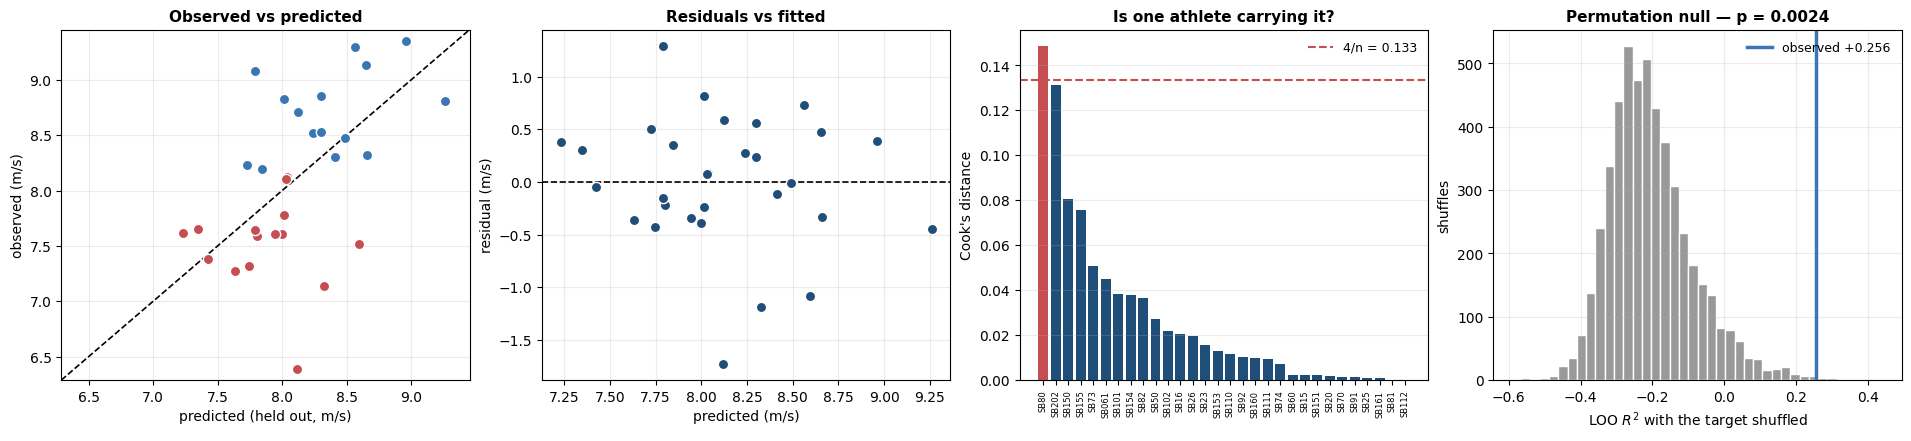

In [15]:
print("saved", OUT.plot_diagnostics(y.values, pred, combo, pids, null, obs_r2).name)

With the target shuffled 5 000 times, the same modelling procedure reaches about
+0.019 at the 95th percentile. The observed +0.256 is far outside that.

**Is one athlete carrying it?** With n = 30 that is a live risk, so it is checked
by removing the most influential athletes rather than assumed away.

In [16]:
inf = SP.influence_report(combo, y.values, pids)
print(inf.head(3).to_string(index=False), f"\n  (flag threshold 4/n = {4/n:.3f})\n")
for drop in ([], ["SB80"], ["SB80", "SB202"], ["SB80", "SB202", "SB150"]):
    k = [i for i, p in enumerate(pids) if p not in drop]
    r2 = SP.fit_metrics(y.values[k], SP.loo_predict(combo[k], y.values[k]))["LOO_R2"]
    print(f"  {'all 30' if not drop else 'minus ' + ', '.join(drop):28} "
          f"LOO R2 = {r2:+.3f}   (n = {len(k)})")

  pid  leverage  residual  cooks_D
 SB80  0.147674 -1.012516 0.148457
SB202  0.061614 -1.623662 0.131404
SB150  0.096550 -0.978299 0.080648 
  (flag threshold 4/n = 0.133)

  all 30                       LOO R2 = +0.256   (n = 30)
  minus SB80                   LOO R2 = +0.316   (n = 29)
  minus SB80, SB202            LOO R2 = +0.412   (n = 28)
  minus SB80, SB202, SB150     LOO R2 = +0.515   (n = 27)


The result **strengthens** as influential athletes are removed — +0.256 on all
30, +0.32 without SB80, +0.41 without SB80 and SB202 — so nobody is manufacturing
it. The +0.256 reported on the full cohort is the conservative number. (These
rows are a robustness check only. Dropping athletes to improve a fit and then
reporting the improved figure would be exactly the practice this notebook is
built to avoid.)

## H · The cost of having chosen

The ladder reports how the winning model scores. It does not report the cost of
having *picked* it — that choice saw all 30 athletes. Here the whole ladder is
re-run inside each fold, the best candidate is chosen there, and only then is the
held-out athlete predicted.

In [17]:
nested_metrics, nested_pred, chosen = SP.nested_cv(specs[:4], y.values)

  nested LOO R2 = +0.256
  model chosen by the inner loop:
    knee ROM + height            30/30 folds


The nested score matches the ladder because the inner loop chose the same model
in **every** fold. Selection stability is what makes that possible; had the
choice wobbled between folds, this number would have dropped and the gap would
have been the price of choosing.

## I · Acceleration — exploratory

Kept separate and clearly labelled. The first three steps out of the blocks have
a **53 % phase spread** against 4 % at top speed, because they are a progression
rather than repetitions — step 1 is not step 3. Their average summarises early
acceleration; it is not a canonical cycle, and features read off it are softer
than the top-speed ones.

In [18]:
ap = [p for p in pids if p in feat["accel"]]
Xa = pd.DataFrame([SP.scalar_features(feat["accel"][p]) for p in ap], index=ap)
ya, ha = y.loc[ap].values, height.loc[ap].values

acc_specs = [
    ("accel: trunk lean + height",  np.column_stack([Xa.trunk_lean_mean, ha]), None,  None),
    ("accel: knee ROM + height",    np.column_stack([Xa.knee_hi_ROM, ha]),     None,  None),
    ("accel: all scalars, ridge",   Xa.values,                                 ridge, None),
]
print(f"n = {len(ap)}")
_acc_table, _ = SP.model_ladder(acc_specs, ya)

n = 30
  accel: trunk lean + height   LOO R2 = +0.231   RMSE = 0.624   MAE = 0.510
  accel: knee ROM + height     LOO R2 = +0.198   RMSE = 0.637   MAE = 0.525
  accel: all scalars, ridge    LOO R2 = +0.010   RMSE = 0.707   MAE = 0.594


Trunk lean out of the blocks predicts top speed about as well as anything found
at top speed itself — which lines up with notebook 01, where trunk lean
correlated r = +0.384 with velocity during acceleration and did essentially
nothing at top speed. Worth a proper look later; not a result on this evidence,
given the phase spread.

## J · What this found

**Kinematics predict velocity, modestly and honestly.** Knee range of motion and
stature together reach **LOO R² = +0.256** on held-out athletes (RMSE ≈ 0.61 m/s
against a cohort spread of 0.72), permutation **p = 0.002**. That is a real
signal and a small one.

**Less knee range of motion goes with faster sprinting.** It is the strongest
single feature in the table at r ≈ −0.60, it survives a largest-of-22 null
(p = 0.009), and
it was found by searching rather than predicted in advance — which is why it is
reported with the permutation test on the whole procedure rather than as a
p-value on a fitted line.

**Selection is the leak that bites, not projection.** Choosing the top-k features
on all 30 athletes and cross-validating only the regression inflates the score by
+0.156 at k = 3 and +0.234 at k = 5. Refitting the choice inside every fold removes it, and the
nested run picks the same model in 30 of 30 folds.

**Twenty-two features are worse than three.** Ridge over the full scalar set
lands below the intercept-only line. With n = 30 the feature set has to be short.

**The fPCA components are not the answer.** They describe the movement well and
predict speed badly, in both codings, whether or not the basis is allowed to
leak. The dominant way these athletes differ is not the way that makes them fast.